<a href="https://colab.research.google.com/github/TalCordova/RS_Coller_TAU_26B/blob/master/notebook1_data_handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: Data Preparation for Recommender Systems

Before building any recommender system, you need to understand your data and make a series of decisions that will affect everything downstream — who to include, how to split, what the data actually represents.

This notebook is about those decisions. We will not build a recommender yet — we will prepare the foundation that makes one possible.

**By the end of this notebook you will be able to:**
1. Explore and understand the structure of RS interaction data
2. Identify and handle data quality issues (sparsity, low-activity users)
3. Choose and implement an appropriate train/test split strategy
4. Understand how each decision affects the system you build

---
> **How to use this notebook:** Read the markdown explanations, run each cell in order, and complete the exercises marked with 🏋️.

## Section 0: Setup

Run the cell below to install and import everything we need.

In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn --quiet

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer plots
plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')
print("✅ All packages loaded")

✅ All packages loaded


---
## Section 1: Load the Data

We use the **MovieLens Small** dataset (~100k ratings from 610 users on 9,742 movies).  
It contains two files:
- `ratings.csv` — `userId`, `movieId`, `rating`, `timestamp`
- `movies.csv` — `movieId`, `title`, `genres`



In [ ]:
import urllib.request, zipfile, io, os

# Download and unzip MovieLens small dataset
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
print("Downloading MovieLens dataset...")
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    zf.extractall(".")
print("✅ Done")

✅ Done


The dataset files (`ratings.csv` and `movies.csv`) have been shared with you via Google Drive.

Before running the cell below, update the two path variables to match where you saved the files in **your own Drive**.

In [ ]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")
movies  = pd.read_csv("ml-latest-small/movies.csv")

print(f"Ratings: {ratings.shape[0]:,} rows | Movies: {movies.shape[0]:,} rows")
ratings.head()

Ratings: 100,836 rows | Movies: 9,742 rows


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Section 2: Exploaratory Data Analysis (EDA)

In [ ]:
# ── Basic counts ───────────────────────────────────────────────────────────
print("=== Dataset Overview ===")
print(f"Total ratings  : {len(ratings):,}")
print(f"Unique users   : {ratings['userId'].nunique():,}")
print(f"Unique movies  : {ratings['movieId'].nunique():,}")
print(f"Avg ratings per user  : {len(ratings) / ratings['userId'].nunique():.1f}")
print(f"Avg ratings per movie : {len(ratings) / ratings['movieId'].nunique():.1f}")

=== Dataset Overview ===
Total ratings  : 100,836
Unique users   : 610
Unique movies  : 9,724
Avg ratings per user  : 165.3
Avg ratings per movie : 10.4


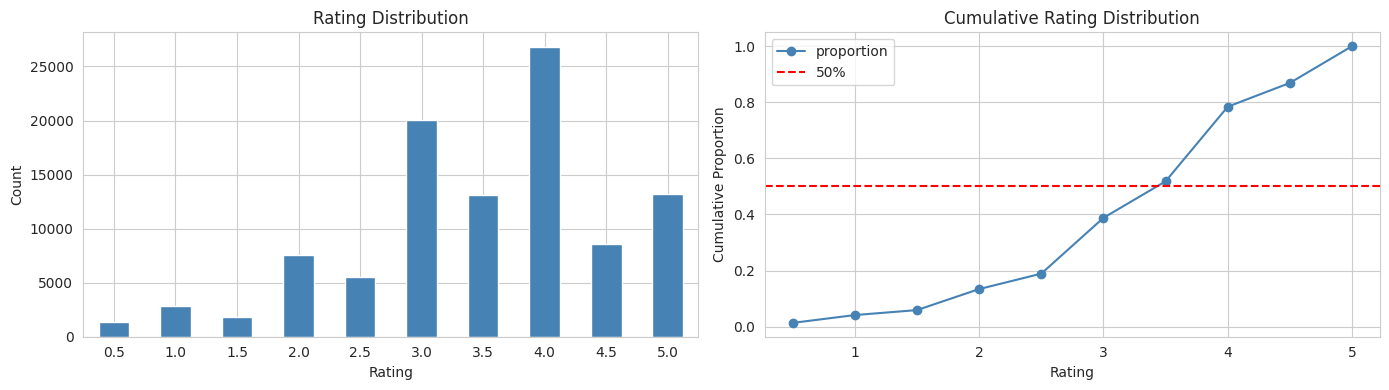

In [ ]:
# ── Rating distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw counts per star value
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Cumulative — shows the skew toward positive ratings
ratings['rating'].value_counts(normalize=True).sort_index().cumsum().plot(
    kind='line', ax=axes[1], marker='o', color='steelblue'
)
axes[1].set_title("Cumulative Rating Distribution")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].axhline(0.5, color='red', linestyle='--', label='50%')
axes[1].legend()

plt.tight_layout()
plt.show()

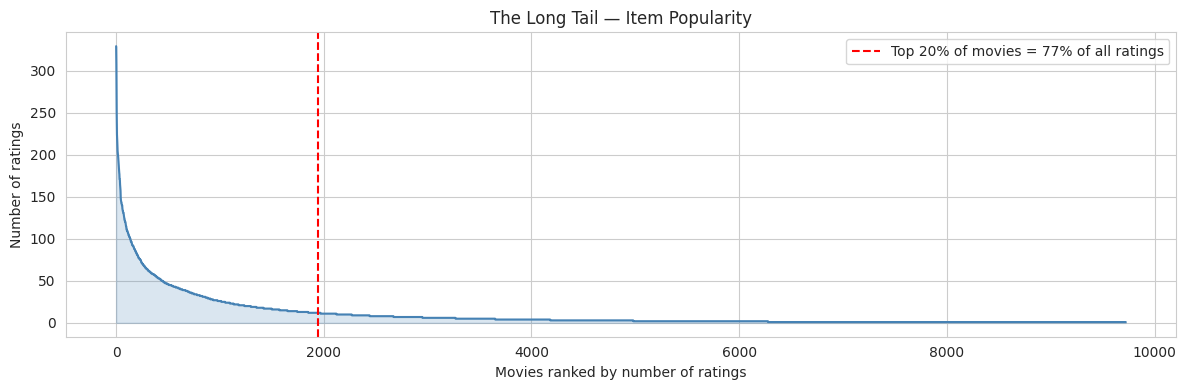

In [ ]:
# ── Long tail: item popularity ─────────────────────────────────────────────
item_popularity = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
item_popularity = item_popularity.reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(item_popularity.values, color='steelblue')
plt.fill_between(range(len(item_popularity)), item_popularity.values, alpha=0.2, color='steelblue')
plt.title("The Long Tail — Item Popularity")
plt.xlabel("Movies ranked by number of ratings")
plt.ylabel("Number of ratings")

# Annotate the head vs tail
head_cutoff = int(len(item_popularity) * 0.2)
head_ratings = item_popularity.iloc[:head_cutoff].sum()
total_ratings = item_popularity.sum()
plt.axvline(head_cutoff, color='red', linestyle='--',
            label=f"Top 20% of movies = {head_ratings/total_ratings:.0%} of all ratings")
plt.legend()
plt.tight_layout()
plt.show()

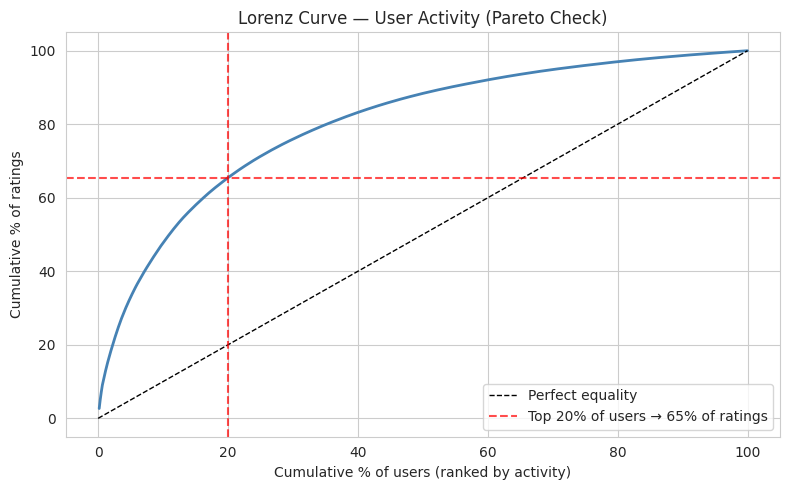

Top 20% of users account for 65.4% of all ratings


In [ ]:
# ── Pareto check: user activity ────────────────────────────────────────────
user_activity = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)
user_activity_sorted = user_activity.reset_index(drop=True)

cumulative_users   = np.arange(1, len(user_activity_sorted) + 1) / len(user_activity_sorted)
cumulative_ratings = user_activity_sorted.cumsum() / user_activity_sorted.sum()

plt.figure(figsize=(8, 5))
plt.plot(cumulative_users * 100, cumulative_ratings * 100, color='steelblue', linewidth=2)
plt.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality')  # diagonal

# Mark the 20/80 point
idx_20 = np.searchsorted(cumulative_users, 0.20)
pct_ratings_by_top20 = cumulative_ratings.iloc[idx_20] * 100
plt.axvline(20, color='red', linestyle='--', alpha=0.7)
plt.axhline(pct_ratings_by_top20, color='red', linestyle='--', alpha=0.7,
            label=f"Top 20% of users → {pct_ratings_by_top20:.0f}% of ratings")

plt.title("Lorenz Curve — User Activity (Pareto Check)")
plt.xlabel("Cumulative % of users (ranked by activity)")
plt.ylabel("Cumulative % of ratings")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top 20% of users account for {pct_ratings_by_top20:.1f}% of all ratings")

---
## Section 3: Data Preparation

Before building any recommender, we need to clean and structure the data.  
We'll go through four steps: exploring sparsity, filtering low-activity users, splitting into train/test, and normalizing ratings.

### 3.1 The Utility Matrix & Sparsity

The core data structure in CF is the **utility matrix** — rows are users, columns are items, and each cell is the rating a user gave an item.

In practice, most cells are empty because no user has watched every movie. This is called **sparsity**, and it's the central challenge in CF.

In [ ]:
# Build the utility matrix
utility_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

n_users, n_items = utility_matrix.shape
n_ratings = ratings.shape[0]
sparsity = 1 - n_ratings / (n_users * n_items)

print(f"Matrix shape  : {n_users} users × {n_items} items")
print(f"Total cells   : {n_users * n_items:,}")
print(f"Filled cells  : {n_ratings:,}")
print(f"Sparsity      : {sparsity:.1%}")  # expect ~98%

Matrix shape  : 610 users × 9724 items
Total cells   : 5,931,640
Filled cells  : 100,836
Sparsity      : 98.3%


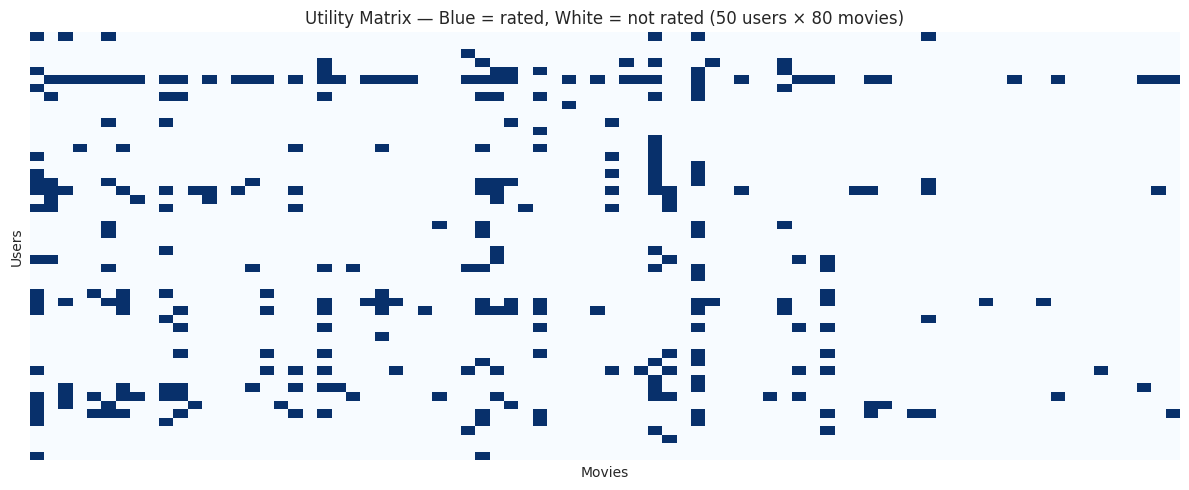

In [ ]:
# Visualize a small slice of the utility matrix
# We sample 50 users and 80 movies to keep the plot readable
sample_users  = utility_matrix.index[:50]
sample_movies = utility_matrix.columns[:80]
sample_matrix = utility_matrix.loc[sample_users, sample_movies]

plt.figure(figsize=(12, 5))
sns.heatmap(
    sample_matrix.notna().astype(int),
    cmap='Blues', cbar=False,
    xticklabels=False, yticklabels=False
)
plt.title("Utility Matrix — Blue = rated, White = not rated (50 users × 80 movies)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

### 3.2 Filtering Low-Activity Users

Users with very few interactions produce noisy similarity signals — if a user rated only 1 movie, we cannot reliably say they are "similar" to anyone.

A common heuristic is to keep only users with **at least 5 ratings**.

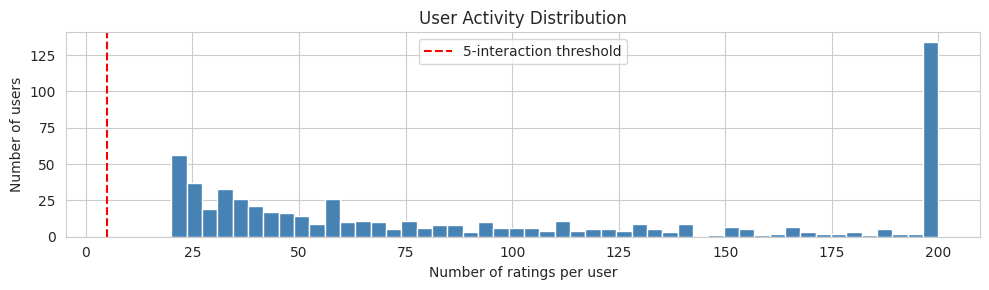

In [ ]:
# Count interactions per user
user_activity = ratings.groupby('userId')['movieId'].count()

# Plot distribution
plt.figure(figsize=(10, 3))
user_activity.clip(upper=200).hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(5, color='red', linestyle='--', label='5-interaction threshold')
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("User Activity Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Keep users with at least 5 interactions
MIN_INTERACTIONS = 5
active_users = user_activity[user_activity >= MIN_INTERACTIONS].index
ratings_filtered = ratings[ratings['userId'].isin(active_users)].copy()

print(f"Users before filtering : {ratings['userId'].nunique()}")
print(f"Users after  filtering : {ratings_filtered['userId'].nunique()}")
print(f"Ratings retained       : {len(ratings_filtered):,} / {len(ratings):,}")

Users before filtering : 610
Users after  filtering : 610
Ratings retained       : 100,836 / 100,836


### 3.3 Data Splitting Strategies

Data for recommender systems is not like typical ML data — it involves different users behaving over time. How you split it is a design decision with real consequences.

There are three common strategies:

| Strategy | How it works | Tradeoff |
|---|---|---|
| **Random** | Randomly hold out X% of all interactions | Simple, but leaks the future into the past |
| **User Temporal** | For each user, hold out their last X% interactions | Guarantees every test user has training history |
| **Global Temporal** | Hold out the last X% of interactions by timestamp | Most realistic for production, but some test users may have no training history |

> ⚠️ **Random split leaks the future into the past.** If a user rated movie A in 2020 and movie B in 2015, a random split might train on A and test on B — the model would be predicting the past from the future. Temporal splits avoid this.

We will use **user temporal split** — it gives us the evaluation guarantee we need: every user in the test set has interaction history in training.

In [30]:
# ── Strategy 1: Random split ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_random, test_random = train_test_split(
    ratings_filtered, test_size=0.2, random_state=42
)
print(f"Random       — train: {len(train_random):,}  test: {len(test_random):,}")


# ── Strategy 2: Global Temporal split ─────────────────────────────────────
ratings_sorted  = ratings_filtered.sort_values('timestamp')
split_idx       = int(len(ratings_sorted) * 0.8)
train_global    = ratings_sorted.iloc[:split_idx].copy()
test_global     = ratings_sorted.iloc[split_idx:].copy()
print(f"Global temp  — train: {len(train_global):,}  test: {len(test_global):,}")


# ── Strategy 3: User Temporal split ───────────────────────────────────────
def user_temporal_split(df, test_frac=0.2):
    """For each user, hold out their most recent interactions as test."""
    train_list, test_list = [], []
    for _, user_df in df.groupby('userId'):
        user_df = user_df.sort_values('timestamp')
        n_test  = max(1, int(len(user_df) * test_frac))
        test_list.append(user_df.iloc[-n_test:])
        train_list.append(user_df.iloc[:-n_test])
    return pd.concat(train_list), pd.concat(test_list)

train_user, test_user = user_temporal_split(ratings_filtered)
print(f"User temp    — train: {len(train_user):,}  test: {len(test_user):,}")

Random       — train: 80,668  test: 20,168
Global temp  — train: 80,668  test: 20,168
User temp    — train: 80,896  test: 19,940


👉 For the rest of the session we will use the **user temporal split** method.

---
## Summary

In this notebook we covered the decisions that every RS practitioner has to make before building anything.

* **Understanding the data**

  > RS interaction data is sparse by nature — most users have rated only a small fraction of the catalog. Before doing anything else, you need to know what you're working with: how many users, how many items, how dense the data is, and where the long tail is.

* **Filtering**

  > Users with very few interactions produce unreliable signals. A common heuristic is to keep only users with at least 5 interactions — but this is a design choice with consequences. It hides cold start from your training data and can amplify popularity bias.

* **Splitting**

  > How you split your data determines what your evaluation actually measures. Random splits leak the future into the past. User temporal split holds out each user's most recent interactions, guaranteeing that every test user has training history. That guarantee matters.

**➡️ In Notebook 2** we define what it means to rank items for a user, how to evaluate a ranked list, and how to train a model that optimizes directly for ranking.